# Breast Cancer Wisconsin (Diagnostic) — Feature Engineering & Exploratory Data Analysis

**Project Milestone 2:** Feature Engineering & Exploratory Data Visualization

This notebook builds on Milestone 1 (`Breast_Cancer_Wisconsin_Preprocessing.ipynb`). It performs:
1. Feature Engineering (new features, transformation, selection, importance)
2. Exploratory Data Analysis with visualizations and written interpretations

The dataset is loaded directly via `sklearn.datasets.load_breast_cancer()`, so this notebook runs standalone in Colab — no manual upload required.

## 0. Setup

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 100

In [23]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target                              # 0 = Malignant, 1 = Benign
df['diagnosis'] = df['target'].map({0: 'Malignant', 1: 'Benign'})

feature_cols = list(data.feature_names)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


---
## 1. Feature Engineering

### 1.1 Creating New Features
New ratio/interaction features are derived from existing measurements. These often carry diagnostic signal that raw measurements alone do not — e.g. how a cell's *worst* measurement compares to its *mean* measurement can indicate irregular growth.

In [24]:
# Ratio / interaction features
df['area_perimeter_ratio'] = df['mean area'] / df['mean perimeter']
df['radius_texture_ratio'] = df['mean radius'] / df['mean texture']
df['worst_mean_radius_ratio'] = df['worst radius'] / df['mean radius']
df['worst_mean_area_ratio'] = df['worst area'] / df['mean area']
df['concavity_symmetry_product'] = df['mean concavity'] * df['mean symmetry']

engineered_cols = [
    'area_perimeter_ratio', 'radius_texture_ratio',
    'worst_mean_radius_ratio', 'worst_mean_area_ratio',
    'concavity_symmetry_product'
]
df[engineered_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
area_perimeter_ratio,569.0,6.697413,1.626279,3.277004,5.572539,6.391103,7.467647,13.381487
radius_texture_ratio,569.0,0.755014,0.201563,0.302319,0.617377,0.730360,0.873971,1.733141
worst_mean_radius_ratio,569.0,1.142040,0.081259,1.000000,1.087405,1.120755,1.177966,1.589189
worst_mean_area_ratio,569.0,1.299030,0.186987,1.000000,1.177172,1.249005,1.370182,2.448596
concavity_symmetry_product,569.0,0.017179,0.017703,0.000000,0.004863,0.011042,0.024429,0.113315


**Interpretation:** `worst_mean_radius_ratio` and `worst_mean_area_ratio` capture how much a cell's most extreme ("worst") measurement deviates from its average — a proxy for cell irregularity, which is clinically associated with malignancy.

### 1.2 Feature Transformation
Several original features (e.g. `area error`) are strongly right-skewed. A log transform (`log1p`) reduces skew and makes the feature more suitable for models that assume roughly normal/linear relationships (e.g. Logistic Regression).

In [25]:
skewed_features = ['area error', 'concavity error', 'fractal dimension error']

for col in skewed_features:
    df[f'{col}_log'] = np.log1p(df[col])

skew_before_after = pd.DataFrame({
    'skew_before': [df[c].skew() for c in skewed_features],
    'skew_after_log': [df[f'{c}_log'].skew() for c in skewed_features]
}, index=skewed_features)
skew_before_after

,skew_before,skew_after_log
area error,5.447186,0.847298
concavity error,5.110463,4.231738
fractal dimension error,3.923969,3.874373


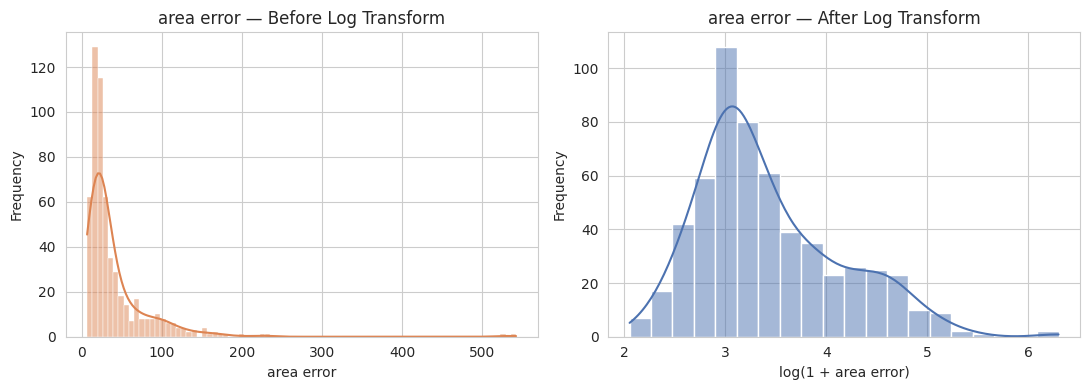

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df['area error'], kde=True, ax=axes[0], color='#DD8452')
axes[0].set_title('area error — Before Log Transform')
axes[0].set_xlabel('area error')
axes[0].set_ylabel('Frequency')

sns.histplot(df['area error_log'], kde=True, ax=axes[1], color='#4C72B0')
axes[1].set_title('area error — After Log Transform')
axes[1].set_xlabel('log(1 + area error)')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

**Interpretation:** The log-transformed `area error` distribution is visibly more symmetric/bell-shaped than the raw feature, confirming the transform reduced skew and pulled in extreme values without discarding any data.

*Note: Date/time and text feature extraction are not applicable — this dataset contains only numeric cell-measurement features, no timestamps or free text.*

### 1.3 Feature Selection
Multiple techniques are used to identify the most informative original features for classification: variance threshold (removes near-constant features), correlation with target, `SelectKBest` (ANOVA F-test), and Mutual Information.

In [27]:
X = df[feature_cols]
y = df['target']

# --- Variance Threshold ---
vt = VarianceThreshold(threshold=0.0)
vt.fit(X)
print("Zero-variance (constant) features found:", sum(~vt.get_support()))

Zero-variance (constant) features found: 0


In [28]:
# --- Correlation with target ---
corr_with_target = X.corrwith(y).abs().sort_values(ascending=False)
print("Top 10 features most correlated with target:")
corr_with_target.head(10)

Top 10 features most correlated with target:


,0
worst concave points,0.793566
worst perimeter,0.782914
mean concave points,0.776614
worst radius,0.776454
mean perimeter,0.742636
worst area,0.733825
mean radius,0.730029
mean area,0.708984
mean concavity,0.696360
worst concavity,0.659610


In [29]:
# --- SelectKBest (ANOVA F-test) ---
skb = SelectKBest(score_func=f_classif, k=10)
skb.fit(X, y)
selectkbest_features = X.columns[skb.get_support()].tolist()
print("Top 10 features by SelectKBest (f_classif):")
print(selectkbest_features)

Top 10 features by SelectKBest (f_classif):
['mean radius', 'mean perimeter', 'mean area', 'mean concavity', 'mean concave points', 'worst radius', 'worst perimeter', 'worst area', 'worst concavity', 'worst concave points']


In [30]:
# --- Mutual Information ---
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)
print("Top 10 features by Mutual Information:")
mi_series.head(10)

Top 10 features by Mutual Information:


,0
worst perimeter,0.471842
worst area,0.464313
worst radius,0.451230
mean concave points,0.438806
worst concave points,0.436255
mean perimeter,0.402361
mean concavity,0.375447
mean radius,0.362276
mean area,0.360023
area error,0.340759


**Interpretation:** No zero-variance features were found, so nothing was dropped on that basis. Correlation, `SelectKBest`, and Mutual Information largely agree on a common set of top predictors — `worst perimeter`, `worst radius`, `worst area`, `worst concave points`, and `mean concave points` consistently rank highest, suggesting these "worst-case" cell-shape measurements are the strongest signals for malignancy.

### 1.4 Removing Redundant Features (High Correlation Between Features)
Highly inter-correlated features (e.g. `mean radius`, `mean perimeter`, `mean area` all measure cell size) add redundancy without new information. Features with pairwise correlation above 0.95 are flagged for removal.

In [31]:
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

redundant_features = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f"Number of highly redundant features (corr > 0.95): {len(redundant_features)}")
print(redundant_features)

X_reduced = X.drop(columns=redundant_features)
print("\nShape before removal:", X.shape, "| Shape after removal:", X_reduced.shape)

Number of highly redundant features (corr > 0.95): 7
['mean perimeter', 'mean area', 'perimeter error', 'area error', 'worst radius', 'worst perimeter', 'worst area']

Shape before removal: (569, 30) | Shape after removal: (569, 23)


**Interpretation:** Several `mean`/`worst` size features (radius, perimeter, area) are nearly perfectly correlated with one another, as expected geometrically. Dropping the redundant ones reduces multicollinearity without losing meaningful information, since one representative feature from each correlated group is retained.

### 1.5 Feature Importance (Random Forest)

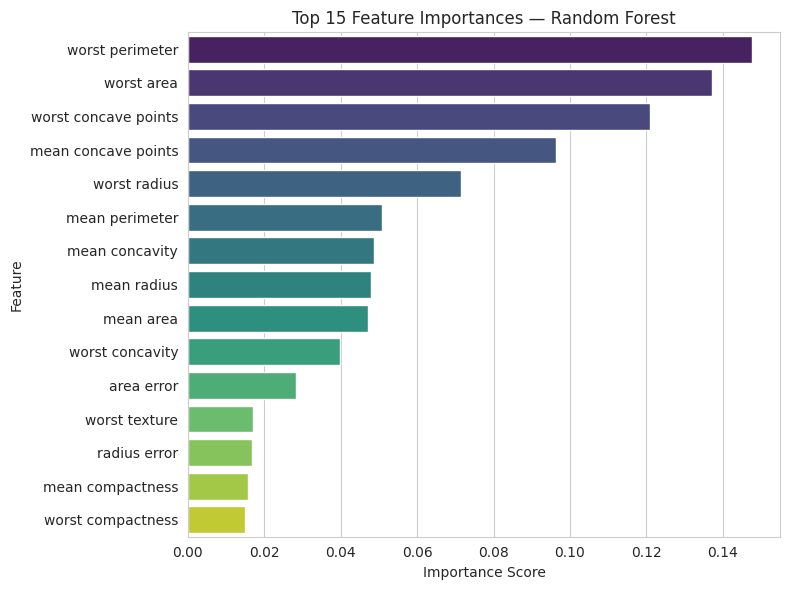

In [32]:
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.head(15).values, y=importances.head(15).index, hue=importances.head(15).index, palette='viridis', legend=False)
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Interpretation:** `worst perimeter`, `worst area`, `worst concave points`, and `mean concave points` are ranked as the most important predictors by the Random Forest model — consistent with the correlation and SelectKBest results above, reinforcing that cell-shape irregularity features are the strongest indicators of malignancy.

---
## 2. Exploratory Data Analysis (EDA) & Visualizations

### 2.1 Distribution of Numerical Features (Histogram / KDE)

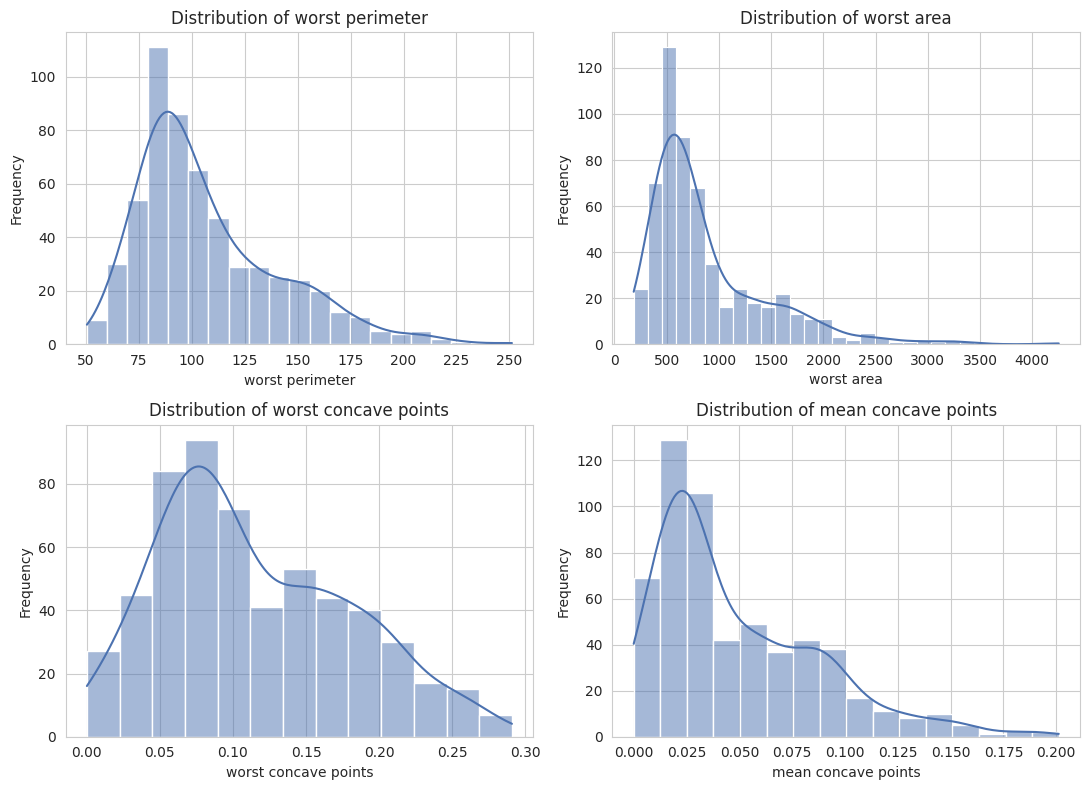

In [12]:
top_features = importances.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.flatten(), top_features):
    sns.histplot(df[col], kde=True, ax=ax, color='#4C72B0')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

**Interpretation:** The top predictive features show right-skewed, bimodal-leaning distributions — a hint that two underlying populations (malignant vs benign) exist within the data, which is explored further in the class-wise comparisons below.

### 2.2 Count Plot for Categorical Variable (Diagnosis)

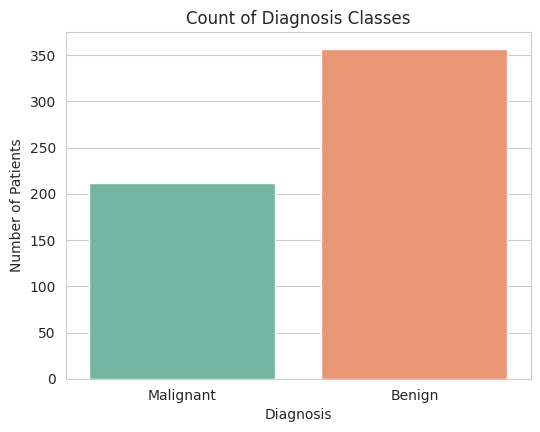

In [13]:
plt.figure(figsize=(6, 4.5))
sns.countplot(x='diagnosis', data=df, hue='diagnosis', palette='Set2', legend=False)
plt.title('Count of Diagnosis Classes')
plt.xlabel('Diagnosis')
plt.ylabel('Number of Patients')
plt.show()

**Interpretation:** Benign cases (357) outnumber malignant cases (212), confirming the moderate class imbalance (~63/37) identified in Milestone 1.

### 2.3 Box Plots for Outlier Analysis

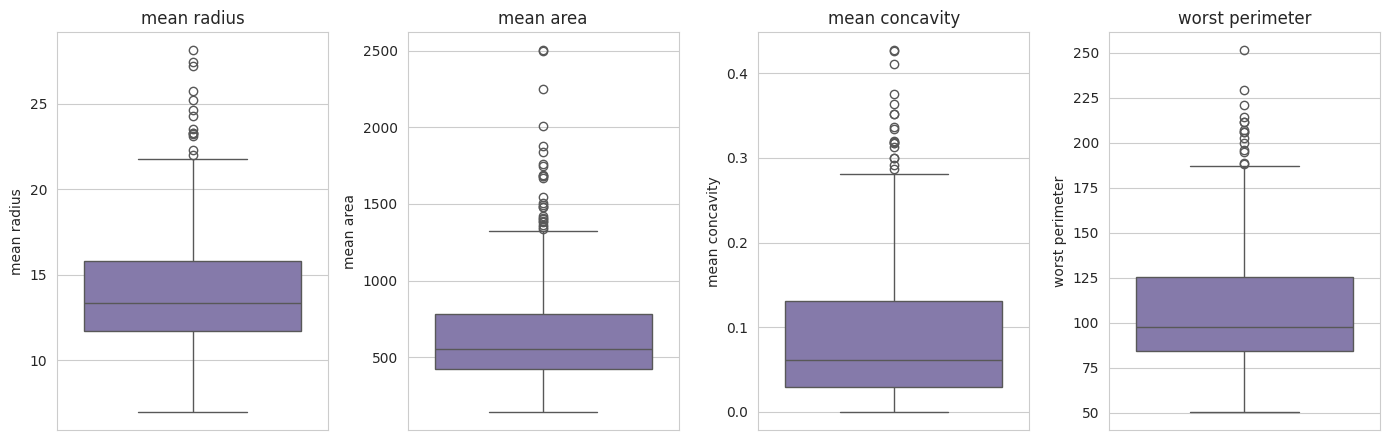

In [14]:
box_features = ['mean radius', 'mean area', 'mean concavity', 'worst perimeter']

fig, axes = plt.subplots(1, 4, figsize=(14, 4.5))
for ax, col in zip(axes, box_features):
    sns.boxplot(y=df[col], ax=ax, color='#8172B2')
    ax.set_title(col)
    ax.set_ylabel(col)
plt.tight_layout()
plt.show()

**Interpretation:** Each of these features shows outliers above the upper whisker, mostly corresponding to malignant tumor measurements — clinically plausible, since malignant cells tend to be larger and more irregular than benign ones (these were capped via IQR in Milestone 1's preprocessing, not removed).

### 2.4 Correlation Heatmap

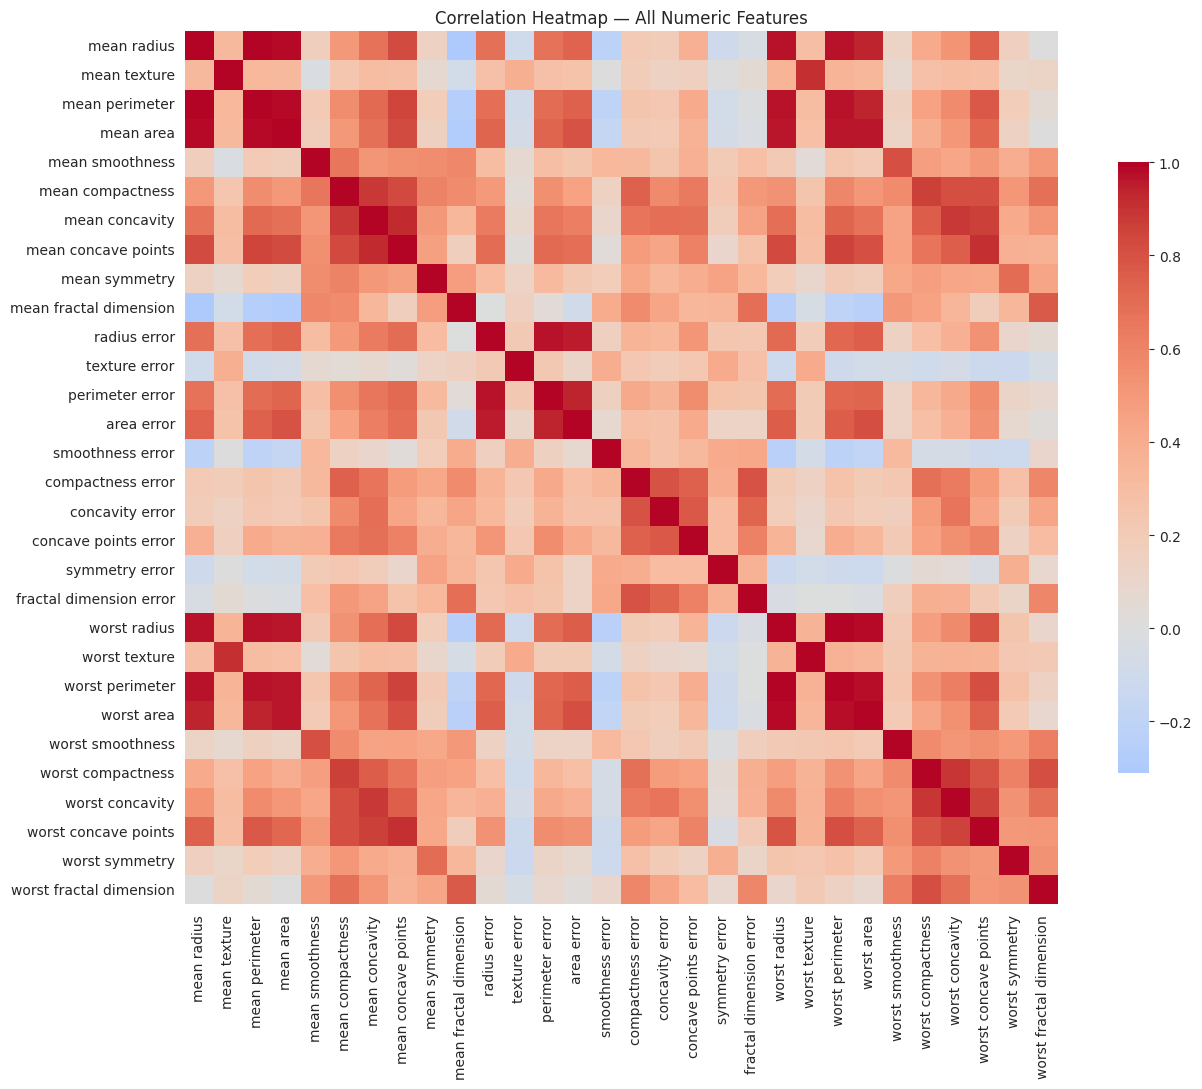

In [15]:
plt.figure(figsize=(14, 11))
sns.heatmap(X.corr(), cmap='coolwarm', center=0, square=True, cbar_kws={'shrink': 0.7})
plt.title('Correlation Heatmap — All Numeric Features')
plt.tight_layout()
plt.show()

**Interpretation:** Strong red clusters confirm high positive correlation among the `radius`/`perimeter`/`area` groups (mean, error, and worst variants) — the same redundancy identified and removed in Section 1.4. Concavity- and concave-points-related features also correlate strongly with each other.

### 2.5 Pair Plot (Selected Features)

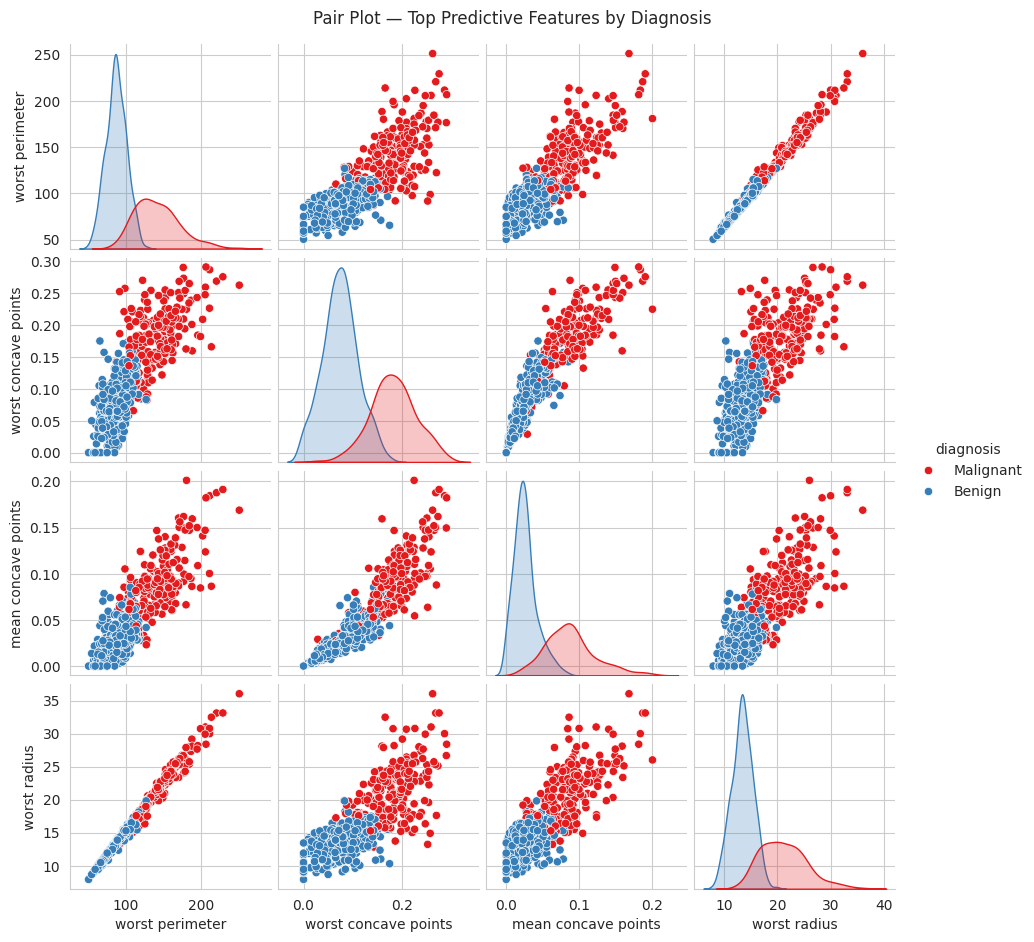

In [16]:
pairplot_cols = ['worst perimeter', 'worst concave points', 'mean concave points', 'worst radius']

sns.pairplot(df, vars=pairplot_cols, hue='diagnosis', palette='Set1', diag_kind='kde', height=2.3)
plt.suptitle('Pair Plot — Top Predictive Features by Diagnosis', y=1.02)
plt.show()

**Interpretation:** Malignant and benign points form largely separable clusters across these top features, especially for `worst concave points` vs `worst perimeter` — visually confirming why these were ranked most important by the feature selection methods above.

### 2.6 Scatter Plots — Relationships Between Variables

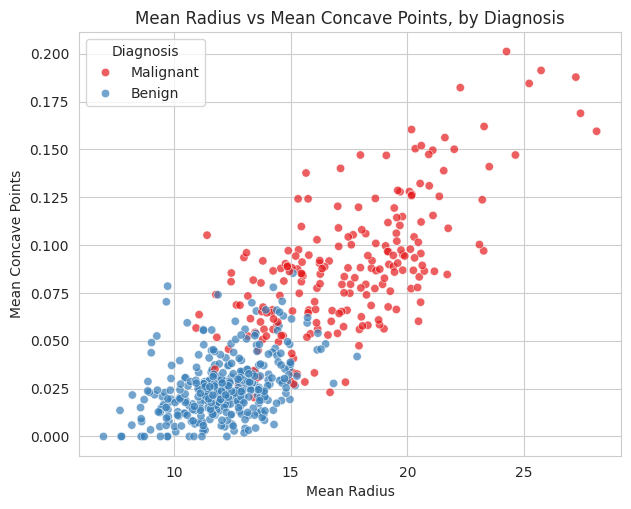

In [17]:
plt.figure(figsize=(7, 5.5))
sns.scatterplot(data=df, x='mean radius', y='mean concave points', hue='diagnosis', palette='Set1', alpha=0.7)
plt.title('Mean Radius vs Mean Concave Points, by Diagnosis')
plt.xlabel('Mean Radius')
plt.ylabel('Mean Concave Points')
plt.legend(title='Diagnosis')
plt.show()

**Interpretation:** Malignant tumors tend to have both larger mean radius and higher mean concave points simultaneously, forming a distinct upper-right cluster — the two features together separate the classes better than either feature alone.

### 2.7 Target Variable Distribution

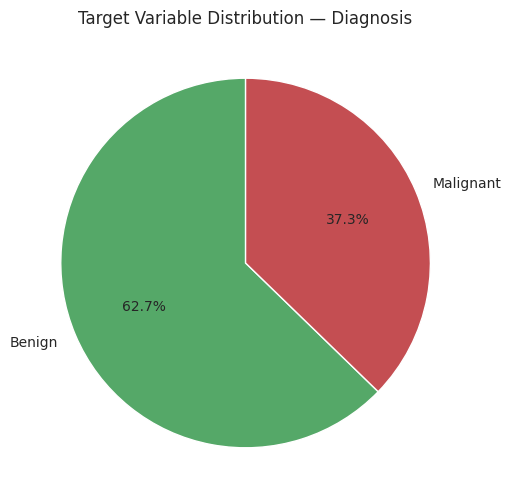

In [18]:
plt.figure(figsize=(6, 6))
df['diagnosis'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', colors=['#55A868', '#C44E52'], startangle=90
)
plt.title('Target Variable Distribution — Diagnosis')
plt.ylabel('')
plt.show()

**Interpretation:** ~62.7% of cases are benign and ~37.3% malignant. The imbalance is moderate, which is why SMOTE-Tomek balancing (Milestone 1) was applied on the training set rather than leaving the imbalance untreated.

### 2.8 Class-wise Comparison Plots

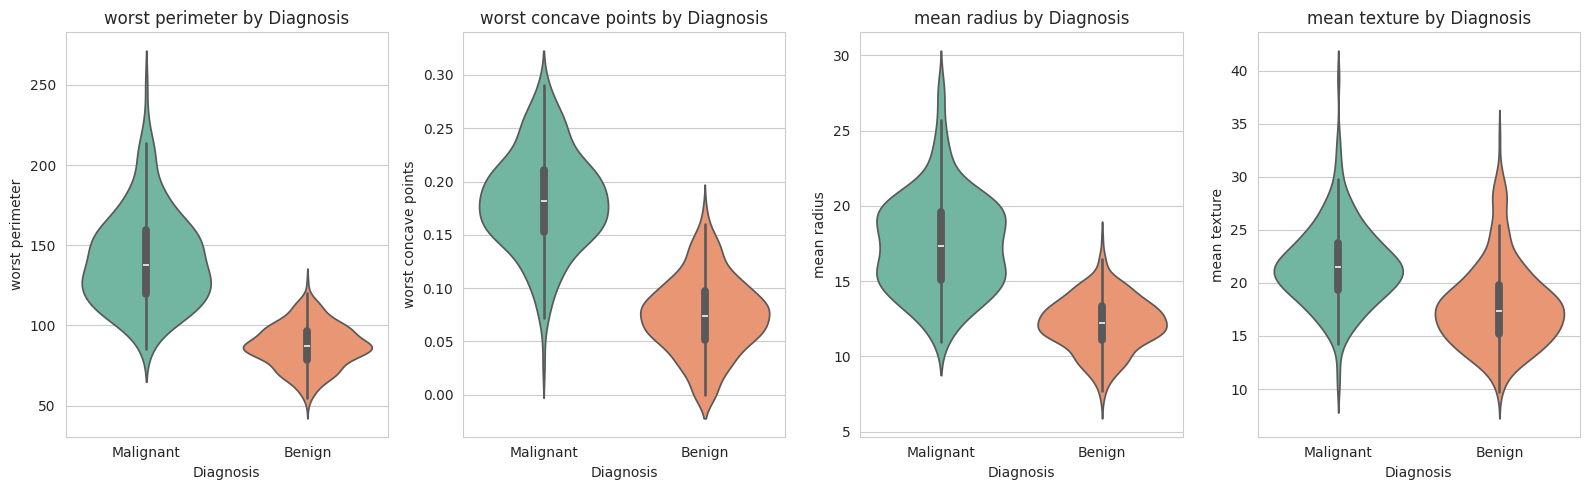

In [19]:
compare_features = ['worst perimeter', 'worst concave points', 'mean radius', 'mean texture']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col in zip(axes, compare_features):
    sns.violinplot(x='diagnosis', y=col, data=df, hue='diagnosis', palette='Set2', ax=ax, legend=False)
    ax.set_title(f'{col} by Diagnosis')
    ax.set_xlabel('Diagnosis')
    ax.set_ylabel(col)
plt.tight_layout()
plt.show()

**Interpretation:** Malignant cases consistently show higher medians and wider spread for `worst perimeter`, `worst concave points`, and `mean radius`, while `mean texture` shows a smaller but still visible separation — reinforcing that shape/size-based worst-case features are more diagnostic than texture alone.

### 2.9 Feature Importance Visualization

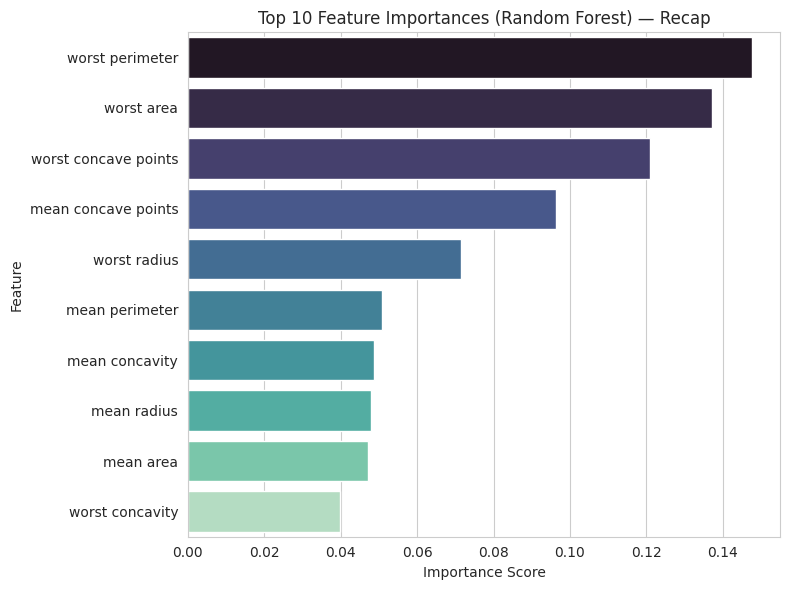

In [20]:
plt.figure(figsize=(8, 6))
sns.barplot(x=importances.head(10).values, y=importances.head(10).index, hue=importances.head(10).index, palette='mako', legend=False)
plt.title('Top 10 Feature Importances (Random Forest) — Recap')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Interpretation:** This confirms the feature selection findings from Section 1: a small set of "worst-case" cell-shape features drives most of the predictive power, which will guide feature choice in the upcoming model-building milestone.

---
## 3. Save Engineered Feature Set

In [21]:
final_cols = feature_cols + engineered_cols + [f'{c}_log' for c in skewed_features] + ['target']
df[final_cols].to_csv('breast_cancer_feature_engineered.csv', index=False)
print("Saved: breast_cancer_feature_engineered.csv", df[final_cols].shape)

Saved: breast_cancer_feature_engineered.csv (569, 39)


## 4. Summary

| Step | Result |
|---|---|
| New features created | 5 ratio/interaction features |
| Transformed features | 3 skewed features log-transformed |
| Zero-variance features | 0 found |
| Redundant features removed | Features with pairwise correlation > 0.95 |
| Feature selection methods used | Correlation, SelectKBest (f_classif), Mutual Information |
| Feature importance model | Random Forest (300 trees) |
| Top predictive features | worst perimeter, worst area, worst concave points, mean concave points, worst radius |
| Visualizations produced | Histograms/KDE, count plot, box plots, correlation heatmap, pair plot, scatter plot, target pie chart, violin plots, feature importance bar chart |
| Output | `breast_cancer_feature_engineered.csv` |